In [1]:
### Notebook for P3D stuff!
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import jax
jax.config.update('jax_platform_name', 'gpu')
from jax.lib import xla_bridge
print("jax version",jax.__version__)
print(xla_bridge.get_backend().platform)

import numpy as np
import jax.numpy as jnp 

%pylab inline

jax version 0.4.28
gpu
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
!nvidia-smi


Thu Aug  7 15:02:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:1A:00.0 Off |                    0 |
| N/A   36C    P0             58W /  300W |   32178MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/home/qiguo/anaconda3/envs/p3d/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [3]:
#from jaxpm.kernels import *
#uses jaxpm for some kernels... maybe?

In [4]:
#First things... set the redshift

z= 2.2

#set box geometry, probably should wrap this into the fiducial model file (hdf5?) to lead to less fiddling bugs

bs =  150#box size in Mpc/h
nc =  150#number of pixels per side

mesh_shape = [nc,nc,nc]
box_size = [bs,bs,bs]

ptcl_grid_shape = (nc,) * 3
ptcl_spacing = bs/nc



In [5]:
#some fourier space routines
from helper_functions import *

kvec = rfftnfreq_2d(ptcl_grid_shape, ptcl_spacing)
k = jnp.sqrt(sum(k**2 for k in kvec))
#this vector is needed for lots of fourier space transformation operations later on...
print(k.shape)

/tmp/ipykernel_1486002/2721841557.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k = jnp.sqrt(sum(k**2 for k in kvec))


(150, 150, 76)


In [6]:
#in this setup, LOS (z) is along the 0 axis, be careful when loading in data!

kz = jnp.ones(k.shape)*kvec[0]**2

kx = jnp.ones(k.shape)*(kvec[1]**2+kvec[2]**2)
#tiny deltas are added to avoid div by zero errors
kk = (kx+kz)+10**(-8)
kmu = jnp.sqrt((kz/(k**2+0.00001)))


In [7]:
np.max(k)


Array(5.441398, dtype=float32)

In [8]:
#m_array[:,0][:50].max()
from jax import jit, checkpoint, custom_vjp
from jax.scipy.ndimage import map_coordinates

#loading in fiducial model
# m_array = np.load("/gpfs02/work/guoqi/P3D/CRO_result/simulation/P3D/pkell_red_CRO_NoBH.npy")
m_array = np.load("./pkell_red_CRO.npy")
m_array = jnp.array(m_array[np.where(m_array[:,1]<=4)])
kmax = m_array[-1,0]
print(m_array.shape,kmax)


(66, 3) 3.2255218


In [9]:
import jaxinterp2d

# for l=0,2,4
# scale k to match the Pk in simulation
k_in = (k.flatten()/kmax*104-0.05)

l0 = np.where(m_array[:,1]==0)[0]
k_l0 = m_array[l0,0]
Pk_l0 = m_array[l0,2]
func1 = map_coordinates(Pk_l0,np.array([k_in]),mode="nearest",order=1)
func1 = func1.reshape(k.shape[0],k.shape[1],k.shape[2])

l2 = np.where(m_array[:,1]==2)[0]
k_l2 = m_array[l2,0]
Pk_l2 = m_array[l2,2]
func2 = map_coordinates(Pk_l2,np.array([k_in]),mode="nearest",order=1)
func2 = func2.reshape(k.shape[0],k.shape[1],k.shape[2])

l4 = np.where(m_array[:,1]==4)[0]
k_l4 = m_array[l4,0]
Pk_l4 = m_array[l4,2]
func4 = map_coordinates(Pk_l4,np.array([k_in]),mode="nearest",order=1)
func4 = func4.reshape(k.shape[0],k.shape[1],k.shape[2])


In [10]:
k_l0

Array([0.11023294, 0.24079579, 0.3849614 , 0.53187305, 0.67934203,
       0.829595  , 0.979204  , 1.1278282 , 1.2777677 , 1.4273715 ,
       1.5772808 , 1.727293  , 1.8769451 , 2.0266526 , 2.1764505 ,
       2.3265052 , 2.4766672 , 2.6267817 , 2.7766607 , 2.9265242 ,
       3.0764768 , 3.2255218 ], dtype=float32)

In [11]:
m_array[:,2].shape

(66,)

In [12]:
# using 20/22 band powers
k_ind_optim_max = 20
ell_bins=3
k_bins=22
tff = m_array[:,2].reshape(ell_bins,k_bins)
theta_fid = m_array[:,2].reshape(ell_bins,k_bins)[:,:k_ind_optim_max]
# theta_fid = m_array[:k_bins,2].reshape(1,k_bins)[:,:k_ind_optim_max]

from scipy.special import legendre

def power_b(theta,tff=tff):    
    tff = tff.at[:,:k_ind_optim_max].set(theta.reshape(ell_bins,k_ind_optim_max))
    # tff = tff.at[0,:k_ind_optim_max].set(theta.reshape(1,k_ind_optim_max).ravel())
    func1 = map_coordinates(tff[0], np.array([k_in]), mode="nearest", order=1)
    func1 = func1.reshape(k.shape[0],k.shape[1],k.shape[2])
    func2 = map_coordinates(tff[1], np.array([k_in]), mode="nearest", order=1)
    func2 = func2.reshape(k.shape[0],k.shape[1],k.shape[2])
    func4 = map_coordinates(tff[2], np.array([k_in]), mode="nearest", order=1)
    func4 = func4.reshape(k.shape[0],k.shape[1],k.shape[2])
    func = jax.nn.relu(func1*legendre(0)(kmu)+func2*legendre(2)(kmu)+func4*legendre(4)(kmu))
    return func


In [13]:
#muse componenet...
from functools import partial
import jax
import jax.numpy as jnp
from muse_inference.jax import JaxMuseProblem

In [14]:

#file name
prefix = "V1_DENSE_"
loc = "./configs/"

# modeled DLA, anisotropy
# SNR becoming smalller now (higher noise level)

naa = np.load(loc+prefix+"naa.npy")
kernel = np.load(loc+prefix+"kernel.npy")
skewers_skn = np.load(loc+prefix+"skewers_skn.npy")
skewers_dla = np.load(loc+prefix+"skewers_dla.npy")
skewers_fin = np.load(loc+prefix+"skewers_fin.npy")

@jit
def cic_readout_jit_jnc(mesh,naa,kernel,bs=False):
    #"highly optimized" CIC, need to preprocess lots of things... don't diff output coords
    meshvals = mesh.flatten()[naa].reshape(-1,8).T#mesh[tuple(neighboor_coords[0,:,:].T.tolist())]
    weightedvals = meshvals.T* kernel[0]
    values = np.sum(weightedvals, axis=-1)
    
    return values



In [15]:
# lin_modes_sim = np.load("./tau_mesh_red_CRO512.npy")
lin_modes_sim = np.load("/gpfs02/work/guoqi/P3D/CRO_result/simulation/CRO-result/CROL200_tau_red_NoBH.npy")
flux_sim = np.exp(-lin_modes_sim)
delta_flux_sim = flux_sim/np.mean(flux_sim)-1

map_lya_sim = cic_readout_jit_jnc(flux_sim,naa,kernel)
key = jax.random.PRNGKey(100)
keys = jax.random.split(key, 2)
map_lya_sim += (1*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],))
# map_lya_sim = np.load("./field_mock/map_lya_sim_NoBH.npy")

In [16]:
# np.save("./field_mock/map_lya_sim_NoBH.npy",map_lya_sim)

In [17]:
tf_cut_flat = theta_fid.flatten()

noise_level = 1.0

def gen_map_lya(theta,z):
    modes = z[:nc**3].reshape((nc,nc,nc))    
    Plin = power_b(theta)
    conv_field = jnp.fft.rfftn(modes).conj()*Plin**(1/2)
    lin_modes_real = jnp.fft.irfftn(conv_field).T[:,:,:]
    flux_real = (lin_modes_real+1)*np.mean(flux_sim)

    lya_values = cic_readout_jit_jnc(flux_real,naa,kernel)
    return lya_values
                 
class Jax3DMuseProblem_flat(JaxMuseProblem):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    #@jax.jit
    def sample_x_z(self, key, θ):
        keys = jax.random.split(key, 2)
        z = jax.random.normal(keys[0], (nc*nc*nc,))
        noise = (1*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],))
        # x = gen_map_lya(θ,z) + (0.05*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],)) #1*jax.random.normal(keys[1], (32**3,)).reshape((32,32,32))
        x = gen_map_lya(θ,z) 
        x_hat = x + noise #1*jax.random.normal(keys[1], (32**3,)).reshape((32,32,32))

        # return (x_hat, z),x,noise
        return (x_hat, z)

  #  @jax.jit
    def logLike(self, x, z, θ):
        # return -(jnp.sum((x - gen_map_lya(θ,z))**2/((0.05*skewers_skn)**2))+ jnp.sum(z**2.0))
        return -(jnp.sum((x-gen_map_lya(θ,z))**2/((1*skewers_skn)**2))+ jnp.sum(z**2.0))

  #  @jax.jit
    def logPrior(self, θ):
        return -jnp.sum(((θ-jnp.array(tf_cut_flat)*1.2)**2 / (2*(tf_cut_flat*0.4)**2)))
    


In [18]:
prob = Jax3DMuseProblem_flat(implicit_diff=True,jit=False)
key = jax.random.PRNGKey(100)
(x, z) = prob.sample_x_z(key, tf_cut_flat)
prob.set_x(map_lya_sim)

In [19]:
modes = z[:nc**3].reshape((nc,nc,nc))    
Plin = power_b(tf_cut_flat)
conv_field = jnp.fft.rfftn(modes).conj()*Plin**(1/2)
lin_modes_real = jnp.fft.irfftn(conv_field).T[:,:,:]

# np.save("example_gen_field",lin_modes_real)

In [20]:
len(z)

3375000

In [21]:
rng = jax.random.PRNGKey(1)

In [22]:
x_data = x

In [23]:
from numpy.random import SeedSequence, default_rng
from copy import copy

start_point = jnp.array(tf_cut_flat)*1.2#+np.random.randn(len(tf_cut_flat))*jnp.array(tf_cut_flat)*0.01)

def _split_rng(rng, N):
    keyz = []
    for i in range(N):
        rng, subkey = jax.random.split(rng)
        keyz.append(rng)
    return keyz
    
θ = start_point

maxsteps = 200
nsims= 10
rng = jax.random.PRNGKey(1)

xz_sims = [prob.sample_x_z(_rng, θ) for _rng in _split_rng(rng, nsims)]
xs = [x_data] + [x for (x,_) in xz_sims]
ẑs = [z*0]     + [z*0 for (x, z) in xz_sims]

In [24]:
print(x_data)

[0.53235453 1.1409779  1.0988729  ... 0.47914642 0.7997277  0.7309741 ]


In [25]:
from jax import grad, hessian, jacfwd, jvp, value_and_grad, vmap

def gradθ_hessθ_logPrior(θ, transformed_θ=None):
        g = grad(prob.logPrior)(θ)
        H = hessian(lambda θ_vec: prob.logPrior(unravel_θ(θ_vec)))(ravel_θ(θ))
        return (g, H)

In [26]:
start_point

Array([ 24.289785  ,  14.470834  ,   6.124267  ,   2.6966372 ,
         1.5168041 ,   1.0029622 ,   0.72133803,   0.55235523,
         0.44190156,   0.36317626,   0.30383694,   0.25746155,
         0.22032681,   0.19043878,   0.16658323,   0.14762579,
         0.13176069,   0.11834945,   0.10748235,   0.09868684,
       -28.985937  , -16.919254  ,  -6.8855157 ,  -2.9127407 ,
        -1.5741521 ,  -0.9839892 ,  -0.6599966 ,  -0.47324744,
        -0.35734808,  -0.2769733 ,  -0.21789563,  -0.17302024,
        -0.13865136,  -0.11110806,  -0.08859605,  -0.07140607,
        -0.05767558,  -0.04642839,  -0.03744369,  -0.03038159,
        12.11094   ,   6.9452357 ,   2.8804002 ,   1.415637  ,
         0.87659794,   0.5712306 ,   0.39922956,   0.31126767,
         0.26067615,   0.22375754,   0.19446138,   0.17188379,
         0.15467198,   0.13911255,   0.12623522,   0.11797328,
         0.11142174,   0.10534491,   0.10022555,   0.09598943],      dtype=float32)

step: 1 0.7
step: 2 0.7
step: 3 0.7
step: 4 0.6649999999999999
step: 5 0.6649999999999999
step: 6 0.6649999999999999


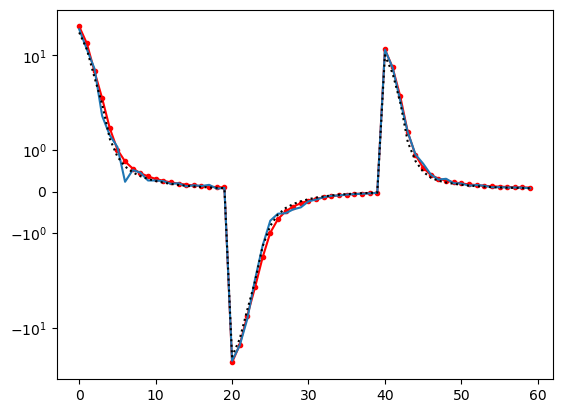

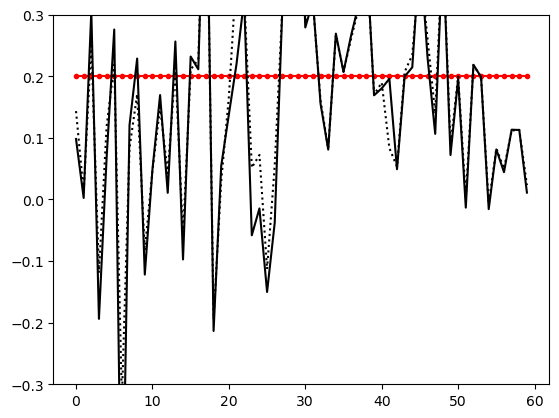

step: 7 0.6317499999999999
step: 8 0.6317499999999999
step: 9 0.6317499999999999
step: 10 0.6001624999999999
step: 11 0.6001624999999999
step: 12 0.6001624999999999


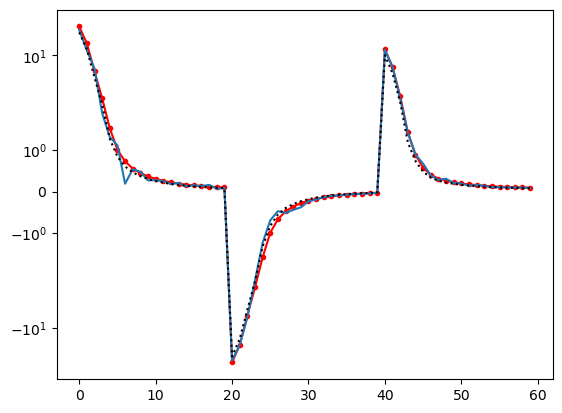

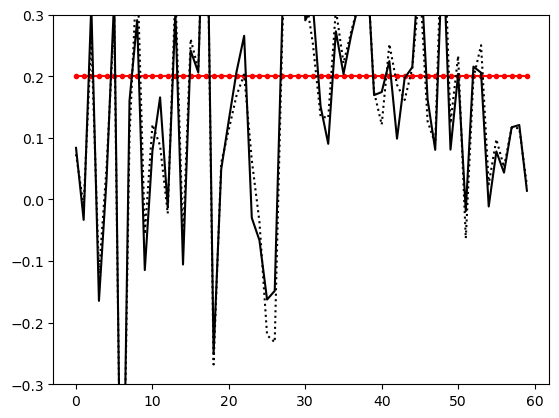

step: 13 0.5701543749999999
step: 14 0.5701543749999999
step: 15 0.5701543749999999
step: 16 0.5416466562499999
step: 17 0.5416466562499999
step: 18 0.5416466562499999


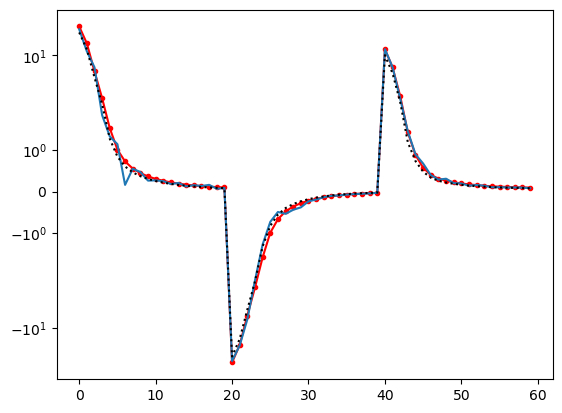

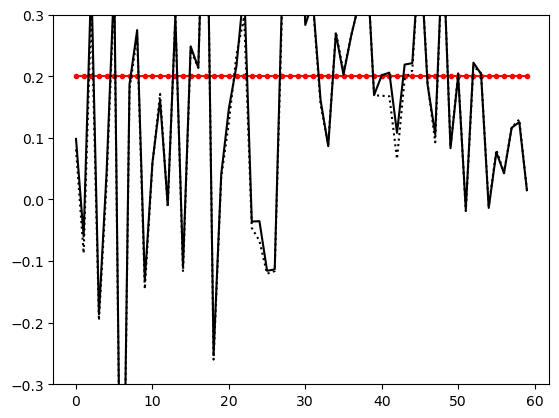

step: 19 0.5145643234374998
step: 20 0.5145643234374998
step: 21 0.5145643234374998
step: 22 0.48883610726562476
step: 23 0.48883610726562476
step: 24 0.48883610726562476


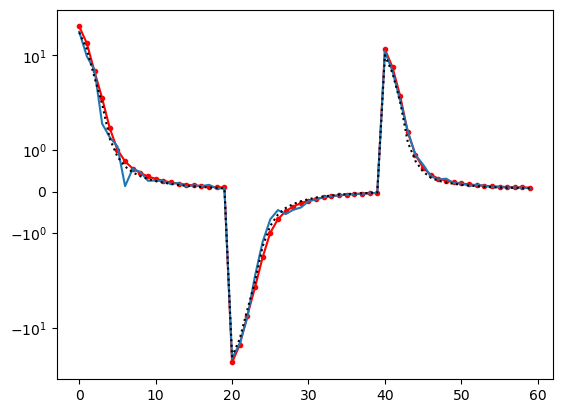

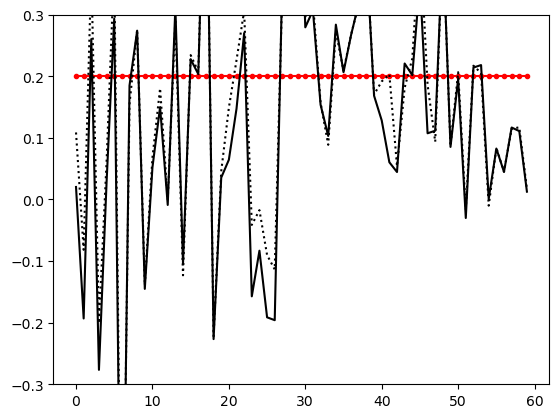

step: 25 0.4643943019023435
step: 26 0.4643943019023435
step: 27 0.4643943019023435
step: 28 0.44117458680722627
step: 29 0.44117458680722627
step: 30 0.44117458680722627


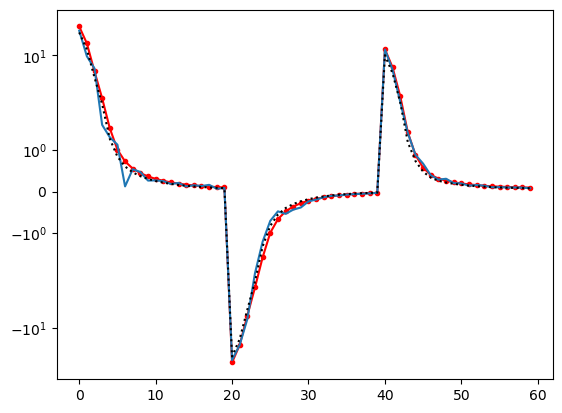

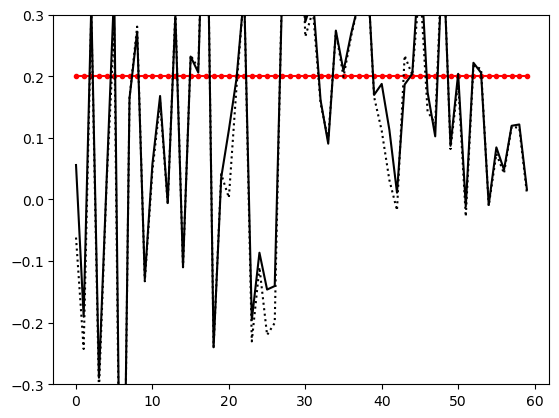

step: 31 0.4191158574668649
step: 32 0.4191158574668649
step: 33 0.4191158574668649
step: 34 0.39816006459352166
step: 35 0.39816006459352166
step: 36 0.39816006459352166


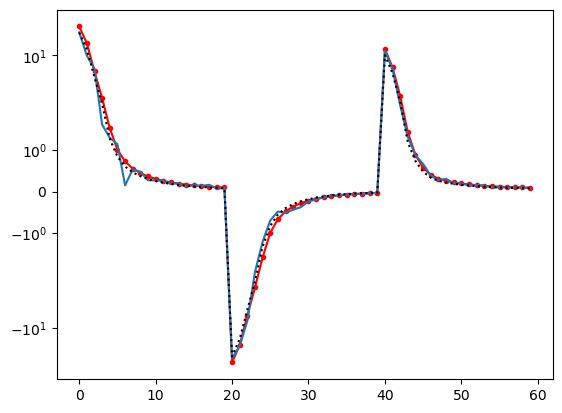

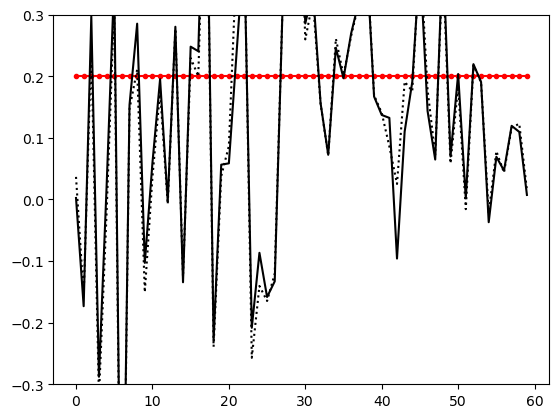

step: 37 0.37825206136384554
step: 38 0.37825206136384554
step: 39 0.37825206136384554
step: 40 0.3593394582956532
step: 41 0.3593394582956532
step: 42 0.3593394582956532


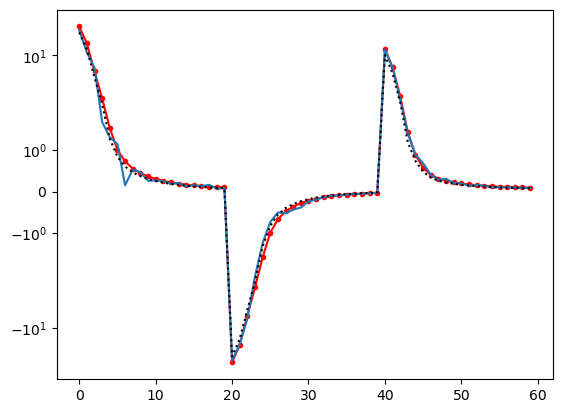

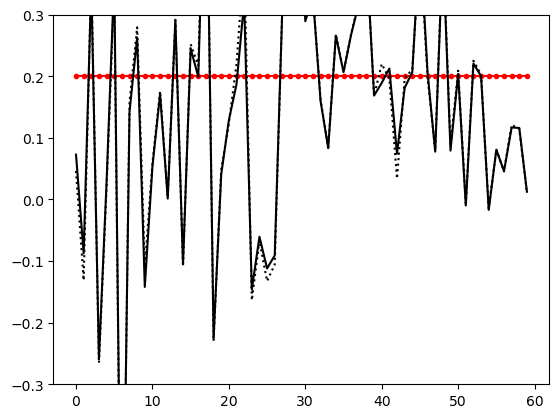

step: 43 0.34137248538087056
step: 44 0.34137248538087056
step: 45 0.34137248538087056
step: 46 0.324303861111827
step: 47 0.324303861111827
step: 48 0.324303861111827


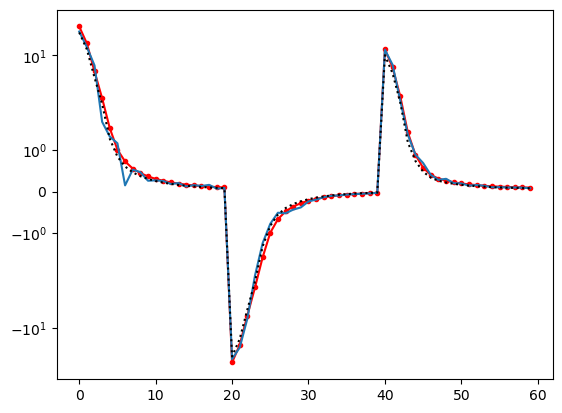

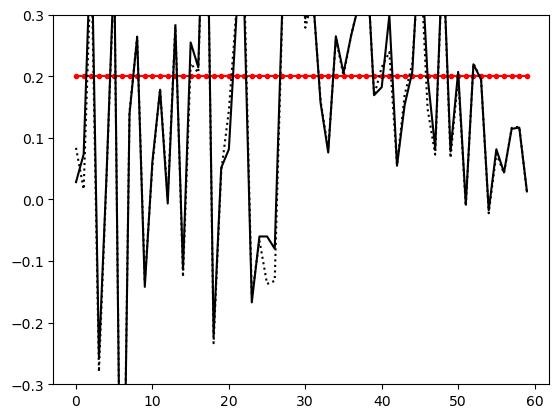

step: 49 0.30808866805623564
step: 50 0.30808866805623564
step: 51 0.30808866805623564
step: 52 0.29268423465342386
step: 53 0.29268423465342386
step: 54 0.29268423465342386


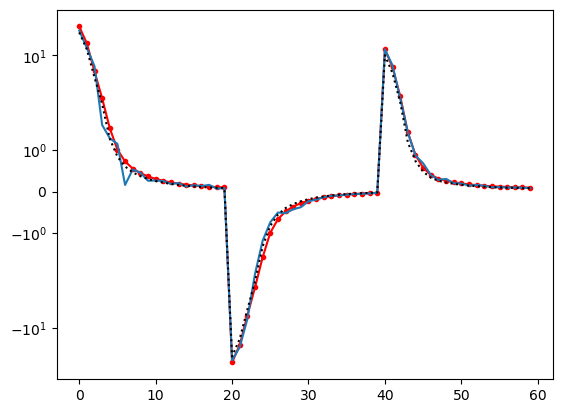

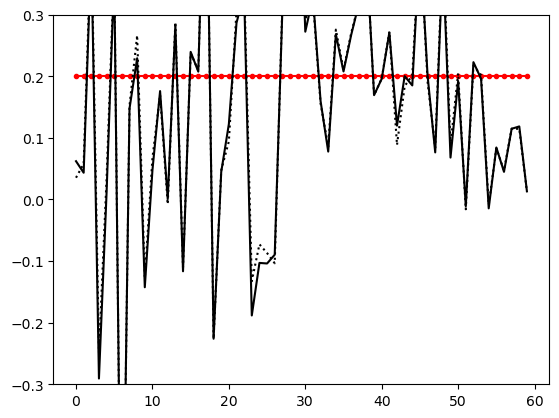

step: 55 0.27805002292075265
step: 56 0.27805002292075265
step: 57 0.27805002292075265
step: 58 0.264147521774715
step: 59 0.264147521774715
step: 60 0.264147521774715


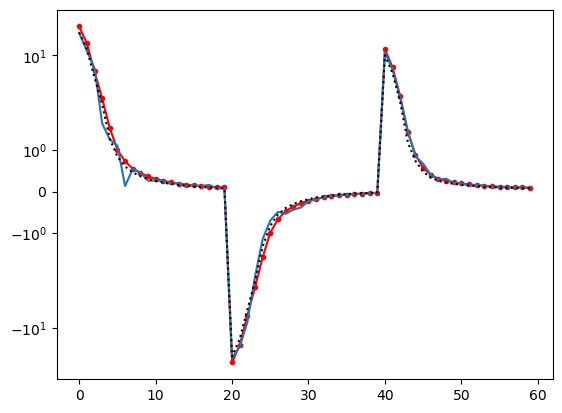

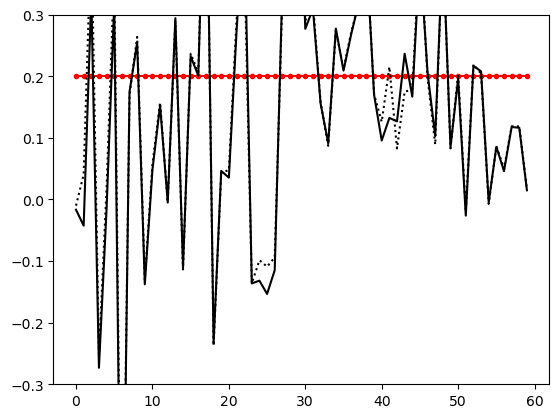

step: 61 0.2509401456859792
step: 62 0.2509401456859792
step: 63 0.2509401456859792
step: 64 0.23839313840168025
step: 65 0.23839313840168025
step: 66 0.23839313840168025


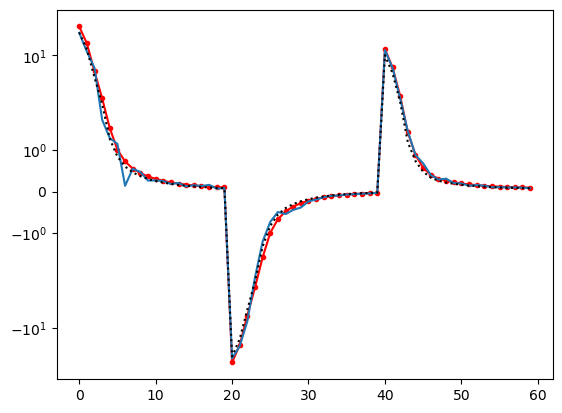

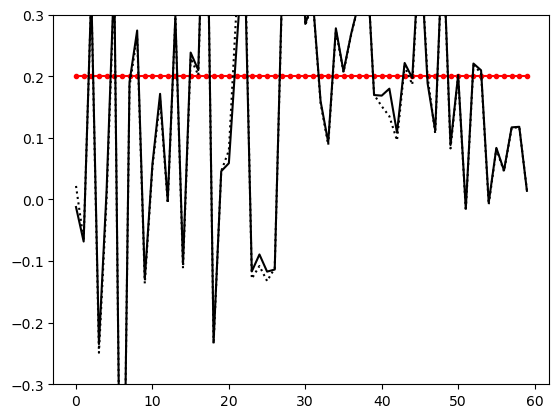

step: 67 0.22647348148159624
step: 68 0.22647348148159624
step: 69 0.22647348148159624
step: 70 0.2151498074075164
step: 71 0.2151498074075164
step: 72 0.2151498074075164


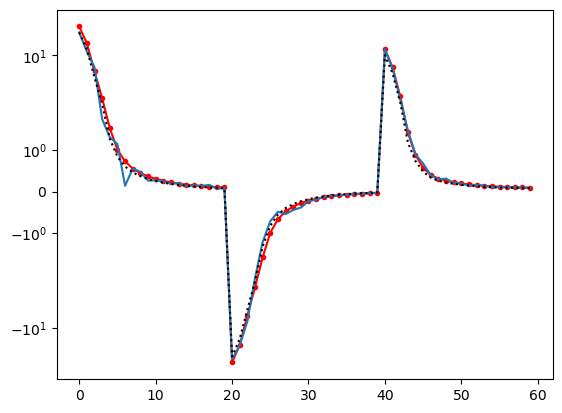

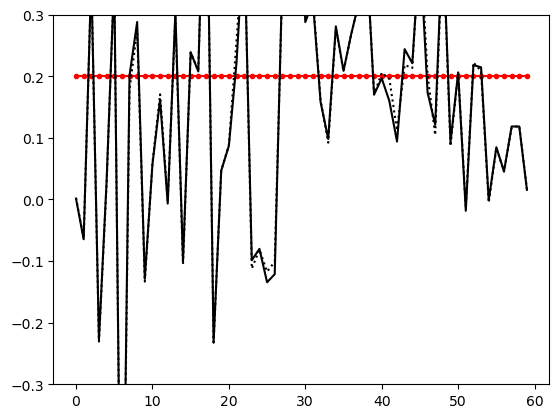

step: 73 0.2043923170371406
step: 74 0.2043923170371406
step: 75 0.2043923170371406
step: 76 0.19417270118528354
step: 77 0.19417270118528354
step: 78 0.19417270118528354


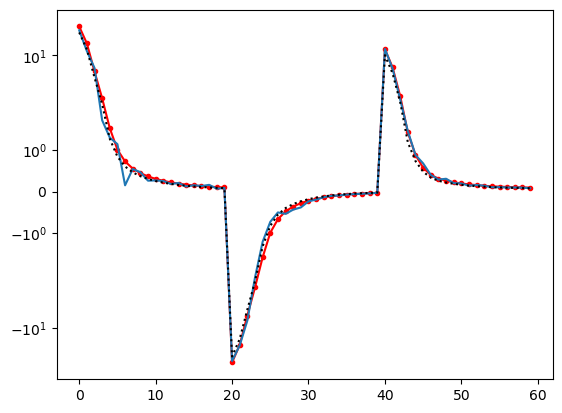

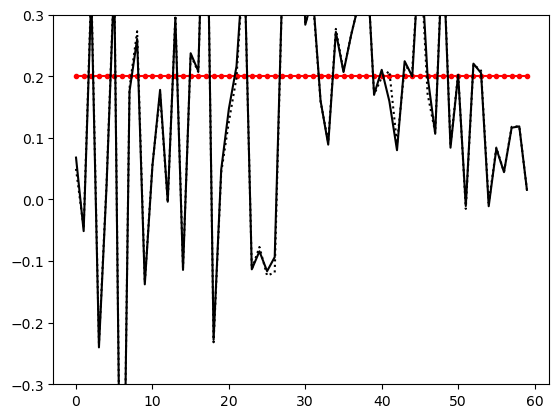

step: 79 0.18446406612601934
step: 80 0.18446406612601934
step: 81 0.18446406612601934
step: 82 0.17524086281971837
step: 83 0.17524086281971837
step: 84 0.17524086281971837


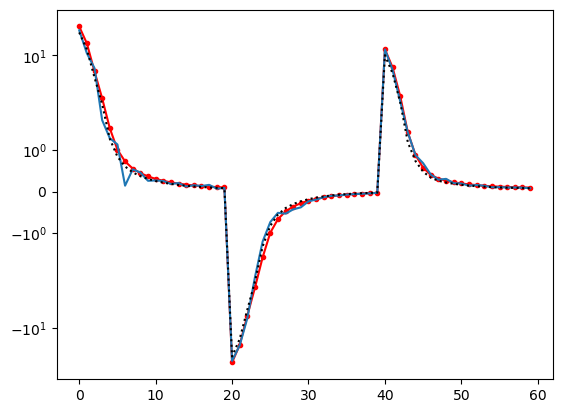

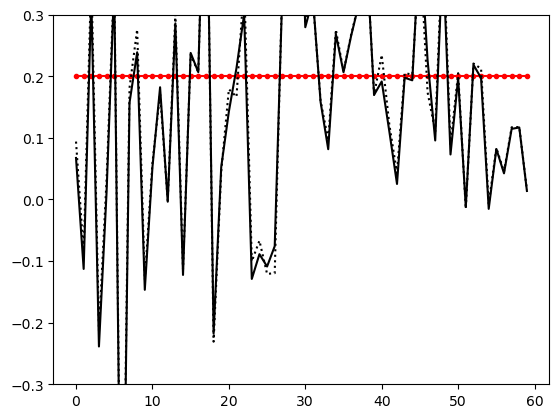

step: 85 0.16647881967873246
step: 86 0.16647881967873246
step: 87 0.16647881967873246
step: 88 0.15815487869479583
step: 89 0.15815487869479583
step: 90 0.15815487869479583


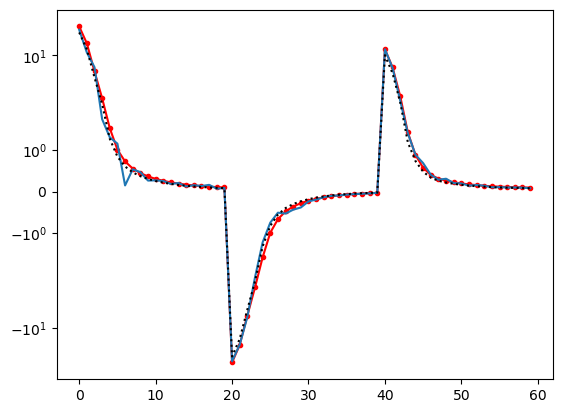

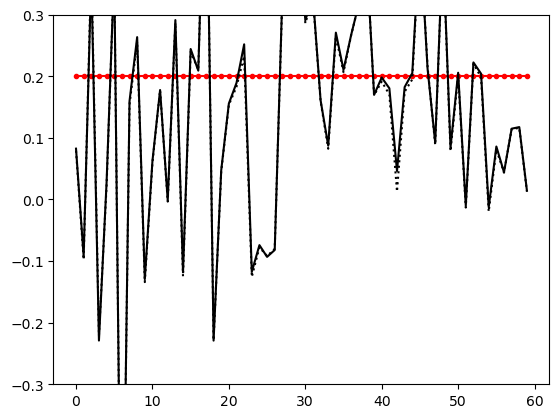

step: 91 0.15024713476005602
step: 92 0.15024713476005602
step: 93 0.15024713476005602
step: 94 0.14273477802205323
step: 95 0.14273477802205323
step: 96 0.14273477802205323


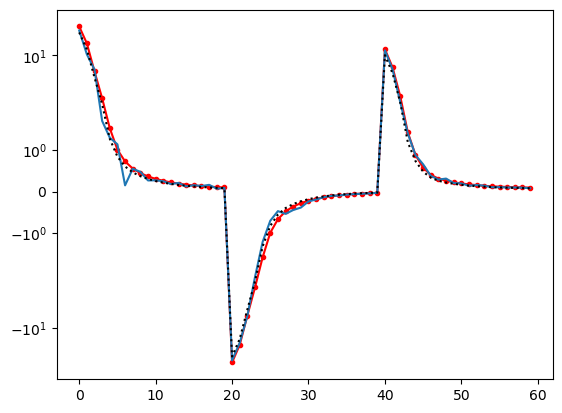

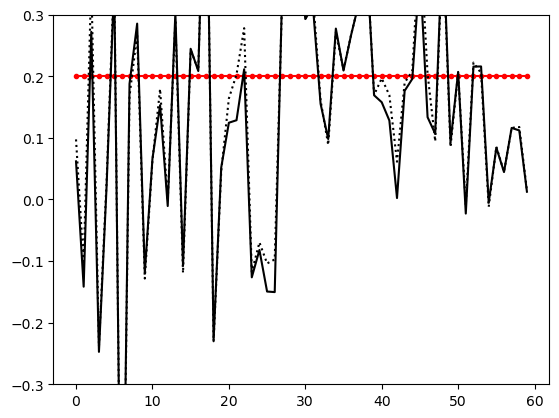

step: 97 0.13559803912095056
step: 98 0.13559803912095056
step: 99 0.13559803912095056
step: 100 0.12881813716490303
step: 101 0.12881813716490303
step: 102 0.12881813716490303


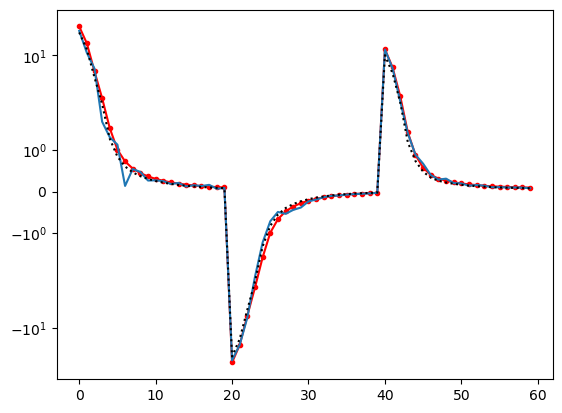

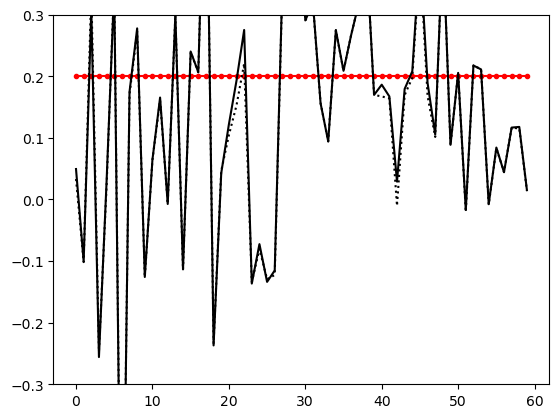

step: 103 0.12237723030665788
step: 104 0.12237723030665788
step: 105 0.12237723030665788
step: 106 0.11625836879132498
step: 107 0.11625836879132498
step: 108 0.11625836879132498


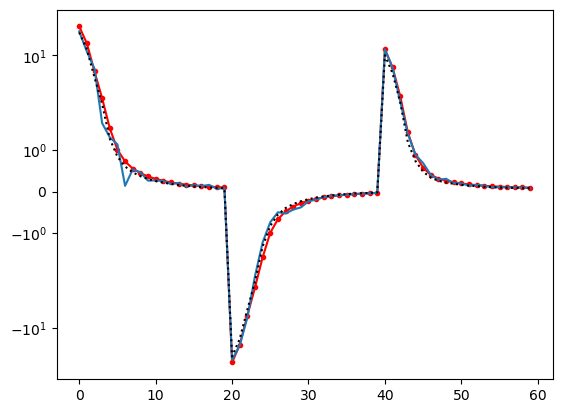

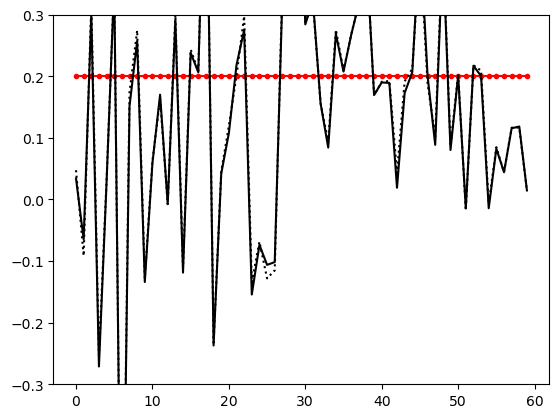

step: 109 0.11044545035175872
step: 110 0.11044545035175872
step: 111 0.11044545035175872
step: 112 0.10492317783417078
step: 113 0.10492317783417078
step: 114 0.10492317783417078


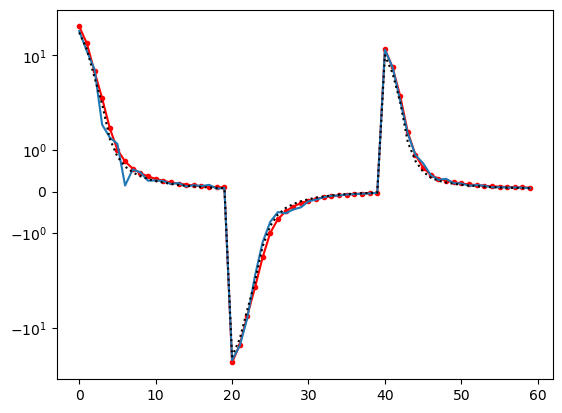

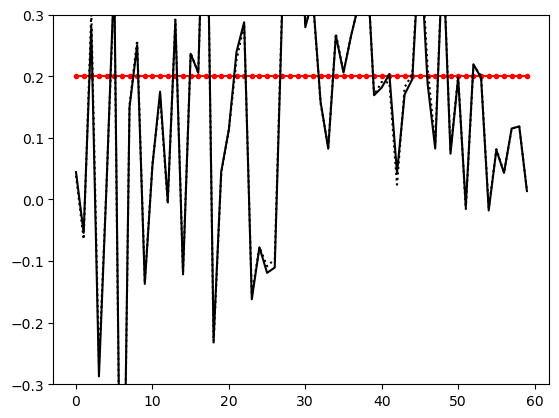

step: 115 0.09967701894246224
step: 116 0.09967701894246224
step: 117 0.09967701894246224
step: 118 0.09469316799533913
step: 119 0.09469316799533913
step: 120 0.09469316799533913


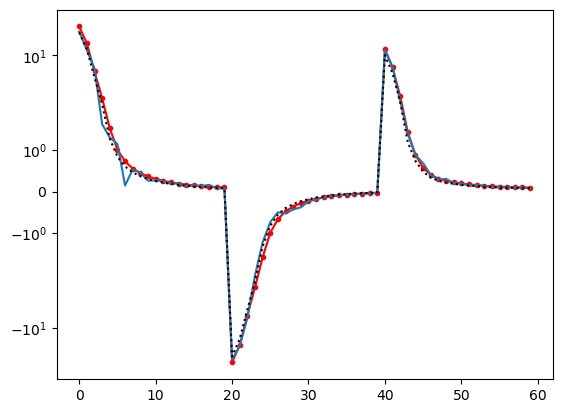

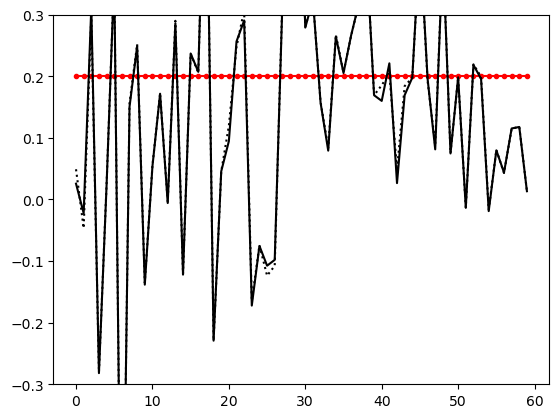

step: 121 0.08995850959557217
step: 122 0.08995850959557217
step: 123 0.08995850959557217
step: 124 0.08546058411579356
step: 125 0.08546058411579356
step: 126 0.08546058411579356


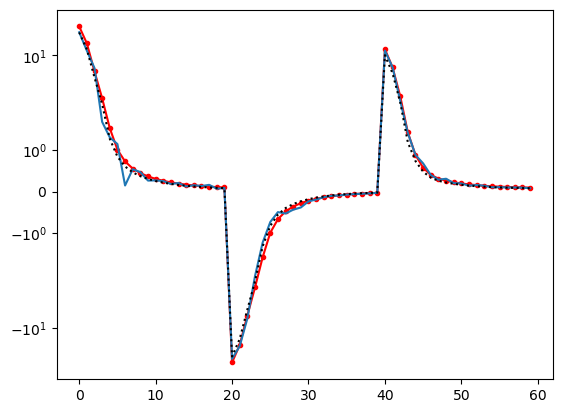

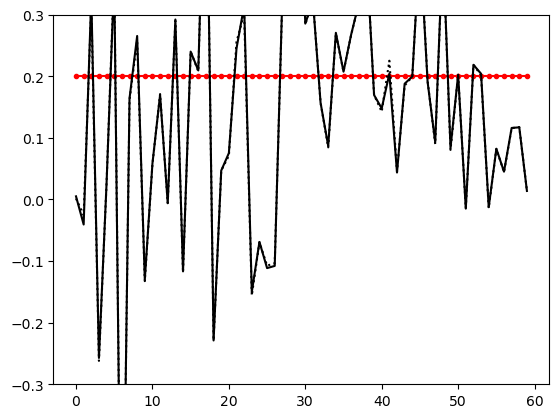

step: 127 0.08118755491000387
step: 128 0.08118755491000387
step: 129 0.08118755491000387
step: 130 0.07712817716450368
step: 131 0.07712817716450368
step: 132 0.07712817716450368


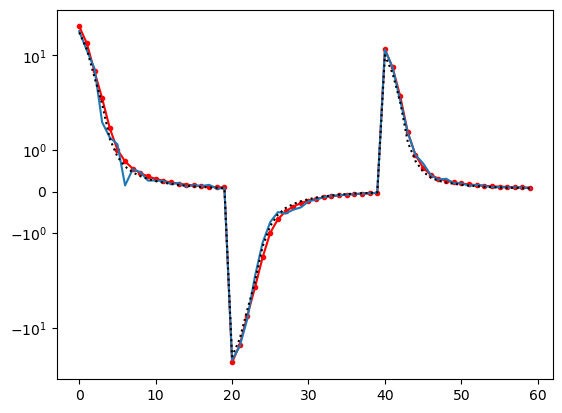

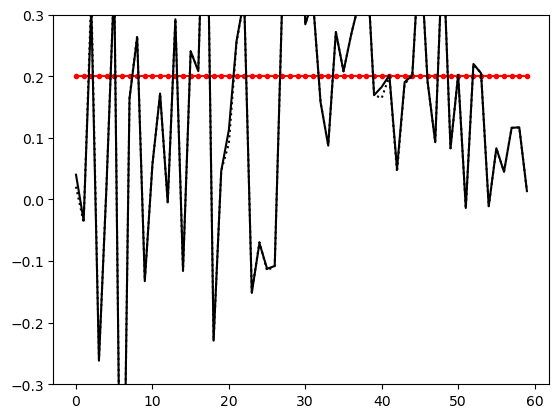

step: 133 0.07327176830627849
step: 134 0.07327176830627849
step: 135 0.07327176830627849
step: 136 0.06960817989096456
step: 137 0.06960817989096456
step: 138 0.06960817989096456


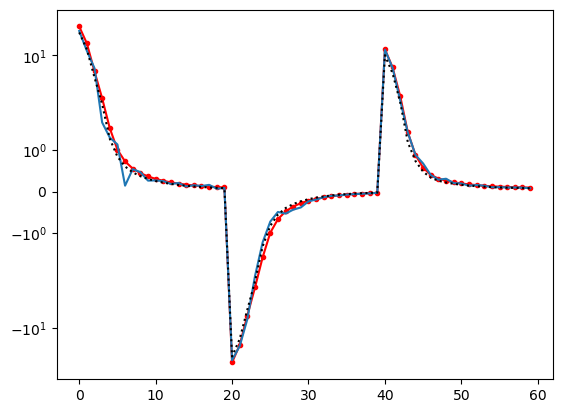

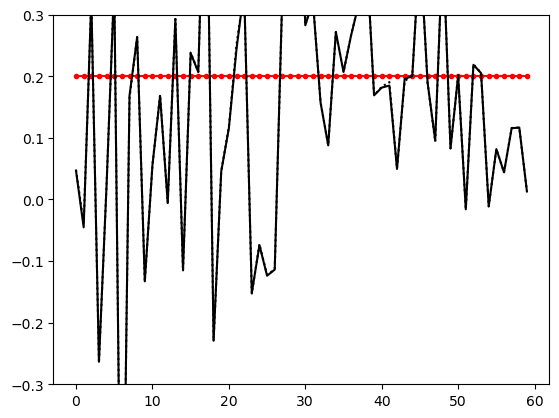

step: 139 0.06612777089641633
step: 140 0.06612777089641633
step: 141 0.06612777089641633
step: 142 0.06282138235159551
step: 143 0.06282138235159551
step: 144 0.06282138235159551


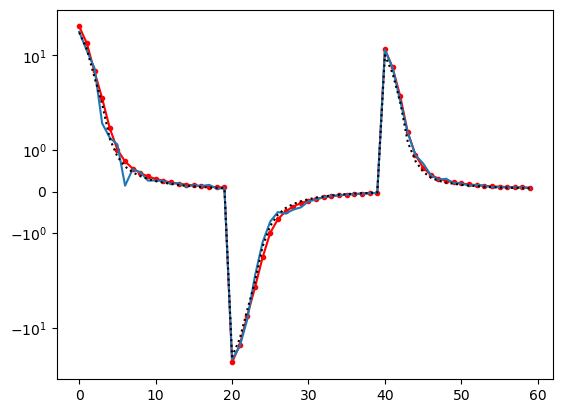

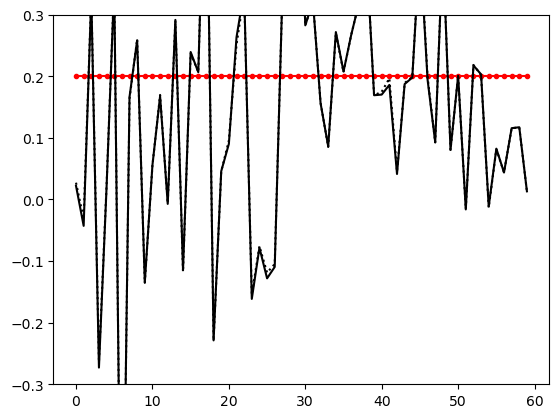

step: 145 0.059680313234015736
step: 146 0.059680313234015736
step: 147 0.059680313234015736
step: 148 0.056696297572314945
step: 149 0.056696297572314945
step: 150 0.056696297572314945


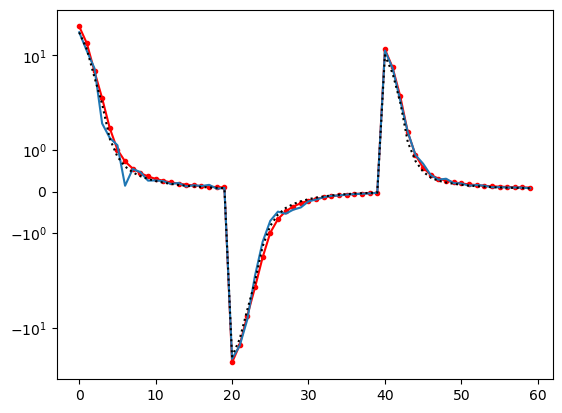

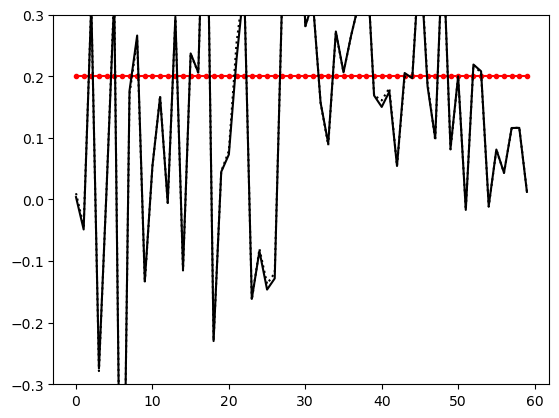

step: 151 0.475
step: 152 0.475
step: 153 0.475
step: 154 0.45125
step: 155 0.45125
step: 156 0.45125


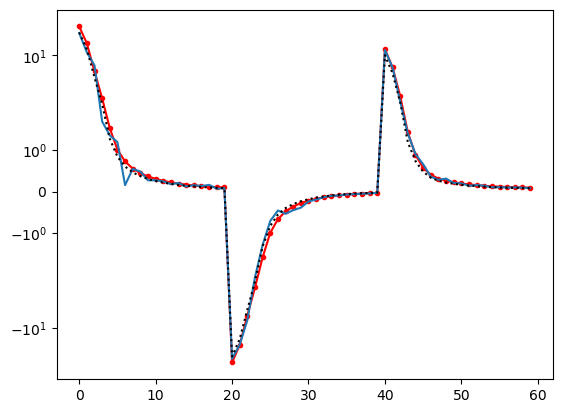

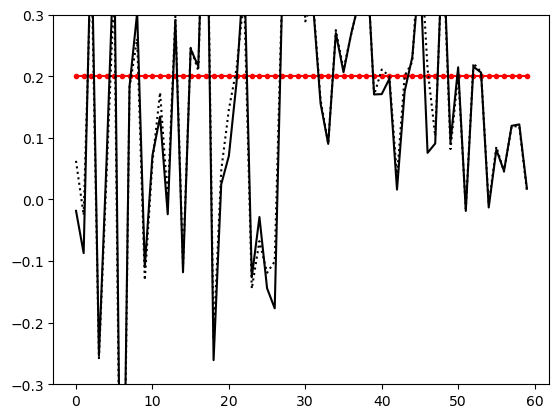

step: 157 0.42868749999999994
step: 158 0.42868749999999994
step: 159 0.42868749999999994
step: 160 0.40725312499999994
step: 161 0.40725312499999994
step: 162 0.40725312499999994


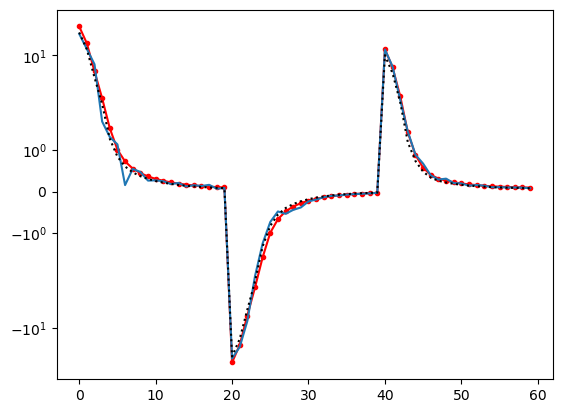

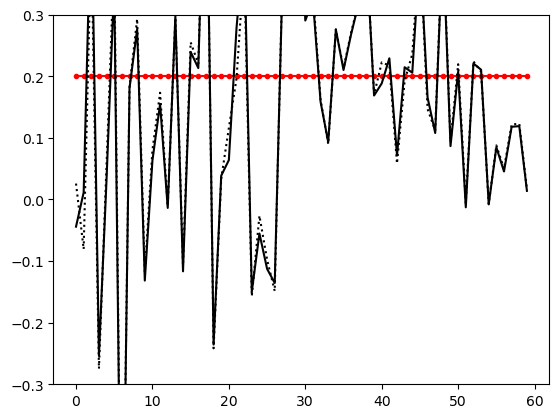

step: 163 0.38689046874999994
step: 164 0.38689046874999994
step: 165 0.38689046874999994
step: 166 0.3675459453124999
step: 167 0.3675459453124999
step: 168 0.3675459453124999


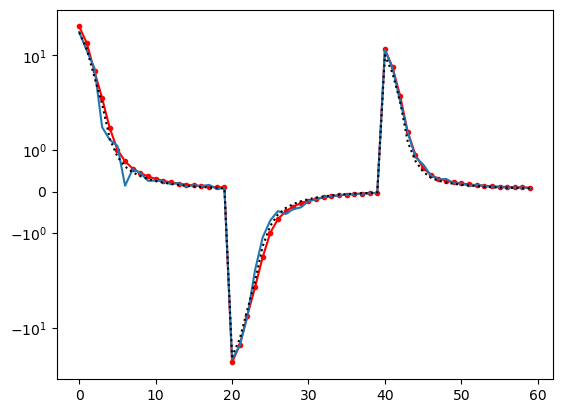

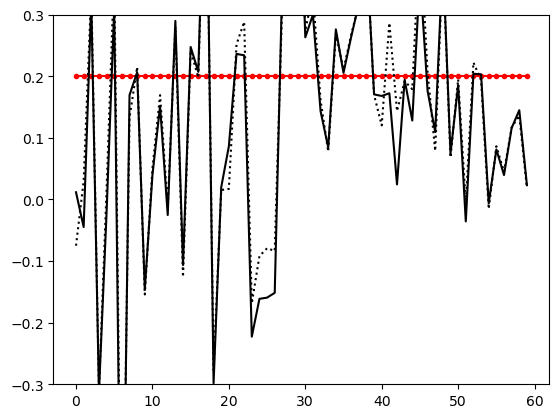

step: 169 0.34916864804687486
step: 170 0.34916864804687486
step: 171 0.34916864804687486
step: 172 0.3317102156445311
step: 173 0.3317102156445311
step: 174 0.3317102156445311


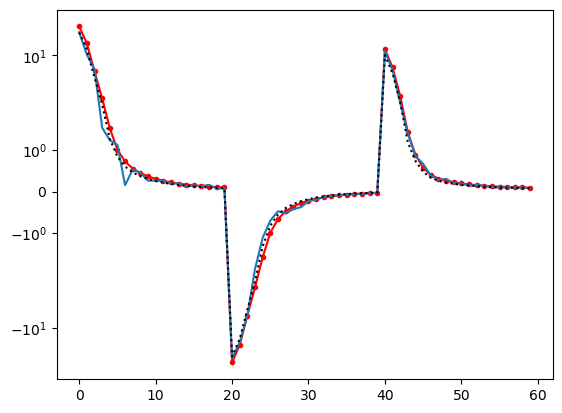

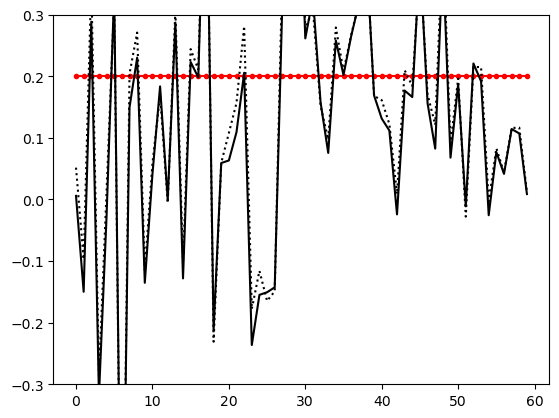

step: 175 0.31512470486230454
step: 176 0.31512470486230454
step: 177 0.31512470486230454
step: 178 0.2993684696191893
step: 179 0.2993684696191893
step: 180 0.2993684696191893


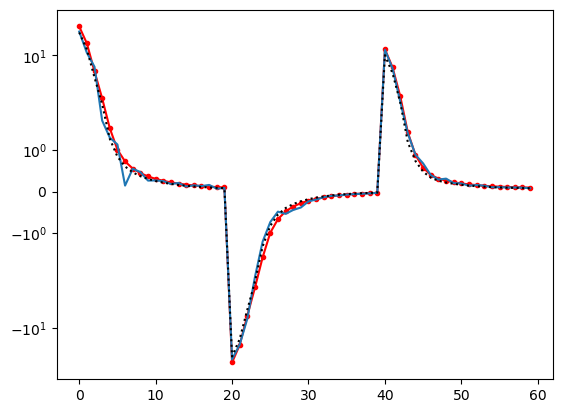

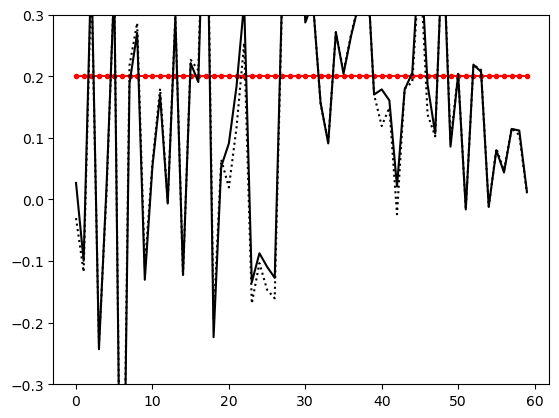

step: 181 0.2844000461382298
step: 182 0.2844000461382298
step: 183 0.2844000461382298
step: 184 0.2701800438313183
step: 185 0.2701800438313183
step: 186 0.2701800438313183


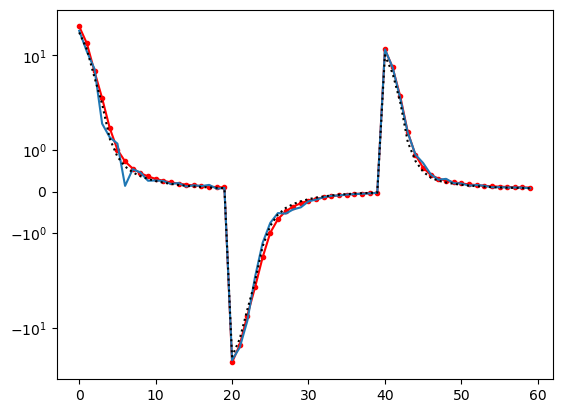

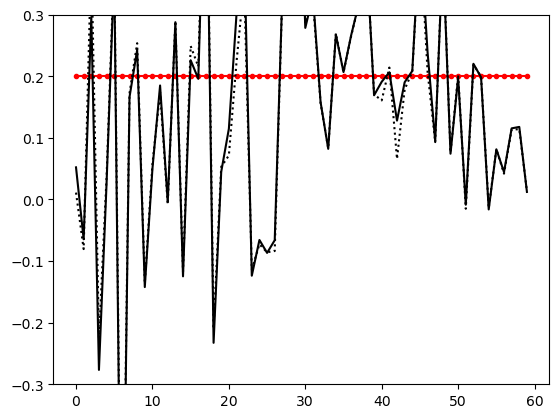

step: 187 0.25667104163975235
step: 188 0.25667104163975235
step: 189 0.25667104163975235
step: 190 0.24383748955776471
step: 191 0.24383748955776471
step: 192 0.24383748955776471


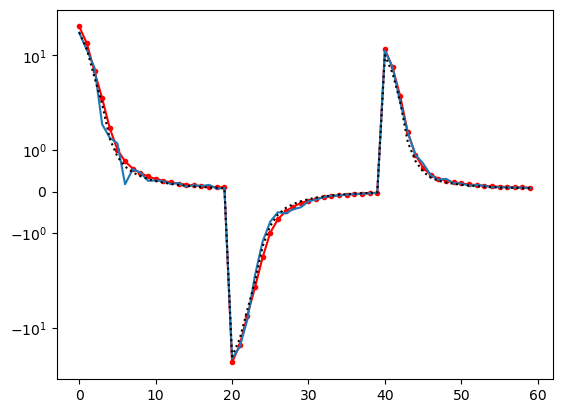

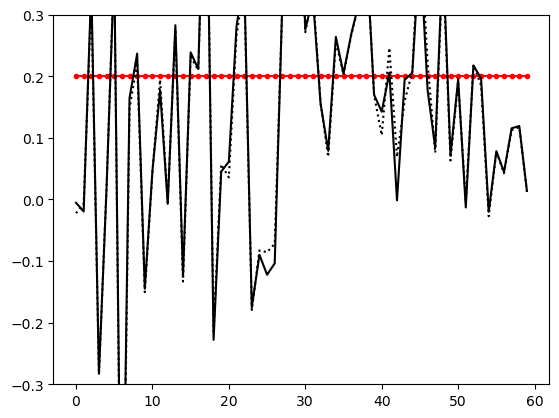

step: 193 0.23164561507987647
step: 194 0.23164561507987647
step: 195 0.23164561507987647
step: 196 0.22006333432588263
step: 197 0.22006333432588263
step: 198 0.22006333432588263


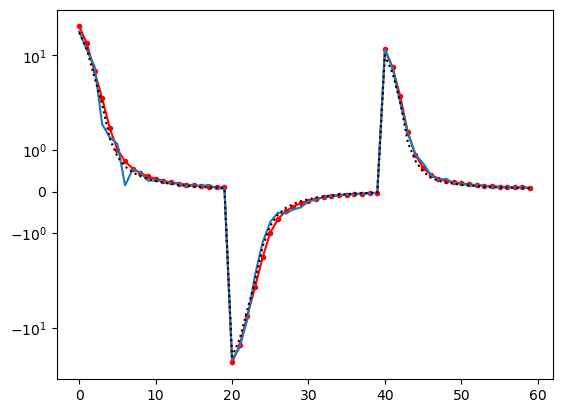

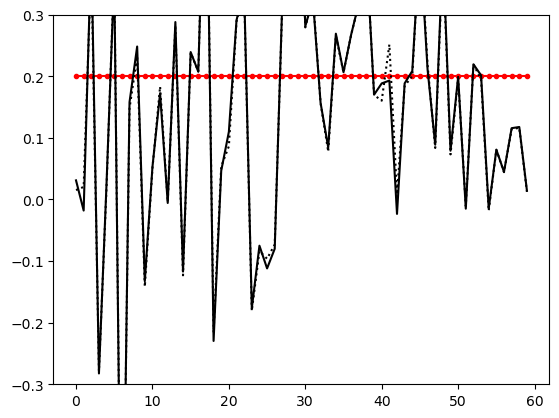

step: 199 0.20906016760958848
step: 200 0.20906016760958848


In [27]:
from datetime import datetime, timedelta
from jax.scipy.optimize import minimize

from multiprocessing.pool import ThreadPool as Pool 
pool = Pool() #jax pmap? check re-compilation times?
pmap = pool.map

#method = 'L-BFGS-B'
method = "l-bfgs-experimental-do-not-rely-on-this"
θ_rtol = 1e-5
z_rtol = 1e-5

θ_tol = 1e-5
z_tol = 1e-6

history = []
α=0.7
beta = 0.25

θ̃ = start_point
θ = start_point# if result.θ is not None else θ_start)
θL = start_point
Nθ = len(ravel_θ(θ̃))
time = timedelta(0)
for i in range(1, maxsteps+1):
        print("step:",i,α)
        t0 = datetime.now()

        if i > 1:
            xs = [x_data] + [prob.sample_x_z(_rng, θ)[0] for _rng in _split_rng(rng,nsims)]
            θ_tol = np.sqrt(-np.diag(H̃_inv_post)) * θ_rtol

        if i > 2:
            Δθ̃ = ravel_θ(history[-1]["θ̃"])- ravel_θ(history[-2]["θ̃"])
          #  if np.sqrt(-np.inner(Δθ̃, np.inner(np.linalg.pinv(history[-1]["H̃_inv_post"]), Δθ̃))) < θ_rtol:
           #     break

        # MUSE gradient
        def get_MAPs(x_z):
            x, ẑ_prev = x_z
            result = prob.z_MAP_and_score(x, ẑ_prev, θ, method=method, z_tol=z_tol, θ_tol=θ_tol)
            
            return result

        MAPs = list(pmap(get_MAPs, zip(xs, ẑs)))

        ẑs = [MAP.z for MAP in MAPs]
   #     if save_MAP_history:
    #        MAP_history_dat, *MAP_history_sims = [MAP.history for MAP in MAPs]
        s_MAP_dat, *s_MAP_sims = [MAP.s for MAP in MAPs]
        s̃_MAP_dat, *s̃_MAP_sims = [MAP.s̃ for MAP in MAPs]
        s̃_MUSE = unravel_θ(ravel_θ(s̃_MAP_dat) - np.nanmean(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0))
        s̃_prior, H̃_prior = gradθ_hessθ_logPrior(θ̃, transformed_θ=True)
        s̃_post = unravel_θ(ravel_θ(s̃_MUSE) + ravel_θ(s̃_prior))

        # print(s̃_MAP_sims)
        # H̃_inv_like_sims = np.diag(-1 / np.nanvar(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0))
        epsilon = 1e-8  # A small value to avoid division by zero
        variance = np.nanvar(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0)
        variance += epsilon  # Add epsilon to the variance to prevent zero values
        H̃_inv_like_sims = np.diag(-1 / variance)
        # print(H̃_inv_like_sims)
        
       # try:
        # H̃_inv_post = np.linalg.pinv(np.linalg.pinv(H̃_inv_like_sims) + ravel_θ(H̃_prior).reshape(Nθ,Nθ))
        H̃_inv_post = np.linalg.pinv(np.linalg.pinv(H̃_inv_like_sims) + ravel_θ(H̃_prior).reshape(Nθ,Nθ))
        #except:
        #    print("error on Hessian inversion calc, prior ignored and trying again...")
       # H̃_inv_post = H̃_inv_like_sims
        t = datetime.now() - t0
        time += t

        history.append({
            "t":t, "θ̃":θ̃, "θ":θ,
            "s_MAP_dat": s_MAP_dat, "s_MAP_sims": s_MAP_sims,
            "s̃_MAP_dat": s̃_MAP_dat, "s̃_MAP_sims": s̃_MAP_sims, 
            "s̃_MUSE": s̃_MUSE,
            "s̃_prior": s̃_prior, "s̃_post": s̃_post, 
            "H̃_inv_post": H̃_inv_post, "H̃_prior": H̃_prior, 
            "H̃_inv_like_sims": H̃_inv_like_sims,
            "θ_tol": θ_tol,
        #    "MAP_history_dat": MAP_history_dat, 
         #   "MAP_history_sims": MAP_history_sims,
        })
        θ̃update = np.clip((np.inner(H̃_inv_post, ravel_θ(s̃_post))),-jnp.abs(ravel_θ(θ̃)*beta),jnp.abs(ravel_θ(θ̃)*beta))
        θ̃ = unravel_θ((ravel_θ(θ̃) - α * θ̃update))
        θ = θ̃
        # print(((θ-tf_cut_flat)/tf_cut_flat))
        #print(θ)
        if i%3==0:
            if i%6==0:
                plt.plot(start_point,"r.-")
                plt.plot(θ)
                plt.plot(tf_cut_flat,"k:")
                plt.yscale("symlog")
                plt.show()
                
                plt.plot((start_point-tf_cut_flat)/tf_cut_flat,"r.-")
                plt.plot((θ-tf_cut_flat)/tf_cut_flat,"k")
                plt.plot((θL-tf_cut_flat)/tf_cut_flat,"k:")
        
                plt.ylim([-.3,.3])
                plt.show()
            
            θL = θ
            #LR decay  after 150 steps, given a higher learning rate
            if i%150==0 and i!=0:
                α = 0.5
            α *= 0.95

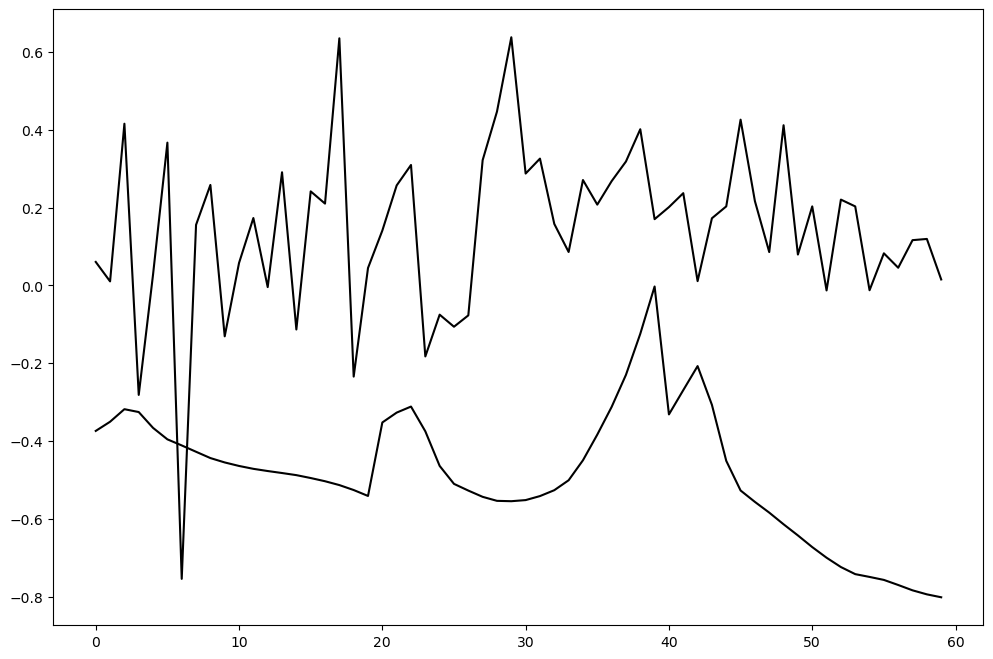

In [28]:
m_array = np.load("/gpfs02/work/guoqi/P3D/CRO_result/simulation/P3D/pkell_red_CRO_NoBH.npy")
m_array = jnp.array(m_array[np.where(m_array[:,1]<=4)])
true_bp = np.concatenate([m_array[np.where(m_array[:,1]==0)][:20,2],m_array[np.where(m_array[:,1]==2)][:20,2],m_array[np.where(m_array[:,1]==4)][:20,2]])

import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(12, 8))

plt.plot(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,color="black",label="fiducial")
plt.plot(np.arange(len(tf_cut_flat)),(true_bp-tf_cut_flat)/tf_cut_flat,color="black",label="fiducial")
